## Expectation Maximisation

In [13]:
import numpy as np


def kalman_filter_em(xs, F, Q, H, R, m0, C0):
    """
    Kalman filter with storage of predicted and filtered moments.

    Here xs has shape (T, d), with x_t observing z_t for t = 0, ..., T-1.
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0.shape[0]

    m_pred = np.zeros((T, n))
    C_pred = np.zeros((T, n, n))
    m_filt = np.zeros((T, n))
    C_filt = np.zeros((T, n, n))
    K_arr = np.zeros((T, n, d))

    loglik = 0.0

    # t = 0: update prior with x_0
    m_pred[0] = m0
    C_pred[0] = C0

    innov = xs[0] - H @ m_pred[0]
    S = H @ C_pred[0] @ H.T + R
    K = C_pred[0] @ H.T @ np.linalg.inv(S)

    m_filt[0] = m_pred[0] + K @ innov
    C_filt[0] = (np.eye(n) - K @ H) @ C_pred[0]
    K_arr[0] = K

    loglik += -0.5 * (
        d * np.log(2 * np.pi)
        + np.log(np.linalg.det(S))
        + innov.T @ np.linalg.solve(S, innov)
    )

    # t = 1, ..., T-1
    for t in range(1, T):
        m_pred[t] = F @ m_filt[t - 1]
        C_pred[t] = F @ C_filt[t - 1] @ F.T + Q

        innov = xs[t] - H @ m_pred[t]
        S = H @ C_pred[t] @ H.T + R
        K = C_pred[t] @ H.T @ np.linalg.inv(S)

        m_filt[t] = m_pred[t] + K @ innov
        C_filt[t] = (np.eye(n) - K @ H) @ C_pred[t]
        K_arr[t] = K

        loglik += -0.5 * (
            d * np.log(2 * np.pi)
            + np.log(np.linalg.det(S))
            + innov.T @ np.linalg.solve(S, innov)
        )

    return {
        "m_pred": m_pred,
        "C_pred": C_pred,
        "m_filt": m_filt,
        "C_filt": C_filt,
        "K": K_arr,
        "loglik": loglik,
    }


def kalman_smoother_em(F, H, filt_out):
    """
    RTS smoother with lag-one smoothed covariances.

    Returns:
      m_smooth[t]  = E[z_t | x_{0:T-1}]
      C_smooth[t]  = Cov(z_t | x_{0:T-1}]
      C_lag[t]     = Cov(z_t, z_{t-1} | x_{0:T-1}] for t >= 1
    """
    m_pred = filt_out["m_pred"]
    C_pred = filt_out["C_pred"]
    m_filt = filt_out["m_filt"]
    C_filt = filt_out["C_filt"]
    K_arr = filt_out["K"]

    T, n = m_filt.shape

    m_smooth = np.zeros_like(m_filt)
    C_smooth = np.zeros_like(C_filt)
    J = np.zeros((T - 1, n, n))

    # C_lag[t] = Cov(z_t, z_{t-1} | x_{0:T-1}) for t = 1, ..., T-1
    C_lag = np.zeros((T, n, n))

    m_smooth[-1] = m_filt[-1]
    C_smooth[-1] = C_filt[-1]

    for t in range(T - 2, -1, -1):
        J[t] = C_filt[t] @ F.T @ np.linalg.inv(C_pred[t + 1])
        m_smooth[t] = m_filt[t] + J[t] @ (m_smooth[t + 1] - m_pred[t + 1])
        C_smooth[t] = C_filt[t] + J[t] @ (C_smooth[t + 1] - C_pred[t + 1]) @ J[t].T

    # Base case for lag-one covariance
    if T >= 2:
        C_lag[T - 1] = (np.eye(n) - K_arr[T - 1] @ H) @ F @ C_filt[T - 2]

    # Backward recursion for lag-one covariance
    for t in range(T - 2, 0, -1):
        C_lag[t] = (
            C_filt[t] @ J[t - 1].T
            + J[t] @ (C_lag[t + 1] - F @ C_filt[t]) @ J[t - 1].T
        )

    return {
        "m_smooth": m_smooth,
        "C_smooth": C_smooth,
        "C_lag": C_lag,
        "J": J,
    }


def em_lgssm(xs, F_init, Q_init, H_init, R_init, m0_init, C0_init,
             tol=1e-4, max_iter=100, verbose=True):
    """
    EM for a time-invariant LGSSM.

    Updates (m0, C0, F, Q, H, R) using the closed-form formulas from the
    smoothing moments.
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0_init.shape[0]

    F = np.asarray(F_init, dtype=float).copy()
    Q = np.asarray(Q_init, dtype=float).copy()
    H = np.asarray(H_init, dtype=float).copy()
    R = np.asarray(R_init, dtype=float).copy()
    m0 = np.asarray(m0_init, dtype=float).copy()
    C0 = np.asarray(C0_init, dtype=float).copy()

    history = {
        "loglik": [],
        "F": [],
        "Q": [],
        "H": [],
        "R": [],
        "m0": [],
        "C0": [],
    }

    for n_iter in range(max_iter):
        # E-step
        filt_out = kalman_filter_em(xs, F, Q, H, R, m0, C0)
        smooth_out = kalman_smoother_em(F, H, filt_out)

        m_s = smooth_out["m_smooth"]
        C_s = smooth_out["C_smooth"]
        C_lag = smooth_out["C_lag"]

        # Sufficient statistics
        A = np.zeros((n, n))
        B = np.zeros((n, n))
        C = np.zeros((n, n))
        XZ = np.zeros((d, n))
        ZZ = np.zeros((n, n))

        for t in range(1, T):
            A += C_s[t - 1] + np.outer(m_s[t - 1], m_s[t - 1])
            B += C_lag[t] + np.outer(m_s[t], m_s[t - 1])
            C += C_s[t] + np.outer(m_s[t], m_s[t])

        for t in range(T):
            XZ += np.outer(xs[t], m_s[t])
            ZZ += C_s[t] + np.outer(m_s[t], m_s[t])

        # M-step
        m0_new = m_s[0]
        C0_new = C_s[0]

        F_new = B @ np.linalg.inv(A)
        Q_new = (C - B @ F_new.T - F_new @ B.T + F_new @ A @ F_new.T) / (T - 1)
        H_new = XZ @ np.linalg.inv(ZZ)

        R_new = np.zeros((d, d))
        for t in range(T):
            diff = xs[t] - H_new @ m_s[t]
            R_new += np.outer(diff, diff) + H_new @ C_s[t] @ H_new.T
        R_new /= T

        # Symmetrise covariance estimates
        Q_new = 0.5 * (Q_new + Q_new.T)
        R_new = 0.5 * (R_new + R_new.T)
        C0_new = 0.5 * (C0_new + C0_new.T)

        # Store history
        history["loglik"].append(filt_out["loglik"])
        history["F"].append(F.copy())
        history["Q"].append(Q.copy())
        history["H"].append(H.copy())
        history["R"].append(R.copy())
        history["m0"].append(m0.copy())
        history["C0"].append(C0.copy())

        # Convergence check
        theta_old = np.concatenate([
            m0.ravel(), C0.ravel(), F.ravel(), Q.ravel(), H.ravel(), R.ravel()
        ])
        theta_new = np.concatenate([
            m0_new.ravel(), C0_new.ravel(), F_new.ravel(), Q_new.ravel(), H_new.ravel(), R_new.ravel()
        ])

        diff = np.linalg.norm(theta_new - theta_old)

        if verbose:
            print(f"iter {n_iter:2d} | loglik = {filt_out['loglik']:.3f} | diff = {diff:.6e}")

        m0, C0, F, Q, H, R = m0_new, C0_new, F_new, Q_new, H_new, R_new

        if diff <= tol:
            break

    return {
        "m0": m0,
        "C0": C0,
        "F": F,
        "Q": Q,
        "H": H,
        "R": R,
        "history": history,
        "filter_out": filt_out,
        "smooth_out": smooth_out,
    }

In [14]:
# Use the same observations from the constant velocity example
# xs has shape (T, 1)

# Initial parameter guess
F_init = np.array([[1.0, 0.5],
                   [0.0, 1.0]])

Q_init = np.array([[0.10, 0.0],
                   [0.0, 0.10]])

H_init = np.array([[1.0, 0.0]])

R_init = np.array([[2.0]])

m0_init = np.array([0.0, 0.0])

C0_init = np.array([[5.0, 0.0],
                    [0.0, 5.0]])

em_out = em_lgssm(
    xs=xs,
    F_init=F_init,
    Q_init=Q_init,
    H_init=H_init,
    R_init=R_init,
    m0_init=m0_init,
    C0_init=C0_init,
    tol=1e-5,
    max_iter=50,
    verbose=True
)

F_em = em_out["F"]
Q_em = em_out["Q"]
H_em = em_out["H"]
R_em = em_out["R"]
m0_em = em_out["m0"]
C0_em = em_out["C0"]

print("\nEstimated parameters")
print("m0 =\n", m0_em)
print("C0 =\n", C0_em)
print("F =\n", F_em)
print("Q =\n", Q_em)
print("H =\n", H_em)
print("R =\n", R_em)

iter  0 | loglik = -87.094 | diff = 6.598577e+00
iter  1 | loglik = -75.191 | diff = 6.845270e-01
iter  2 | loglik = -73.385 | diff = 2.635606e-01
iter  3 | loglik = -72.897 | diff = 1.336168e-01
iter  4 | loglik = -72.661 | diff = 7.991059e-02
iter  5 | loglik = -72.505 | diff = 5.309034e-02
iter  6 | loglik = -72.384 | diff = 3.781354e-02
iter  7 | loglik = -72.286 | diff = 2.828873e-02
iter  8 | loglik = -72.201 | diff = 2.196315e-02
iter  9 | loglik = -72.127 | diff = 1.756746e-02
iter 10 | loglik = -72.061 | diff = 1.440956e-02
iter 11 | loglik = -72.000 | diff = 1.208412e-02
iter 12 | loglik = -71.945 | diff = 1.033966e-02
iter 13 | loglik = -71.893 | diff = 9.012619e-03
iter 14 | loglik = -71.846 | diff = 7.992224e-03
iter 15 | loglik = -71.801 | diff = 7.200868e-03
iter 16 | loglik = -71.758 | diff = 6.582630e-03
iter 17 | loglik = -71.718 | diff = 6.096312e-03
iter 18 | loglik = -71.679 | diff = 5.711067e-03
iter 19 | loglik = -71.642 | diff = 5.403537e-03
iter 20 | loglik = -

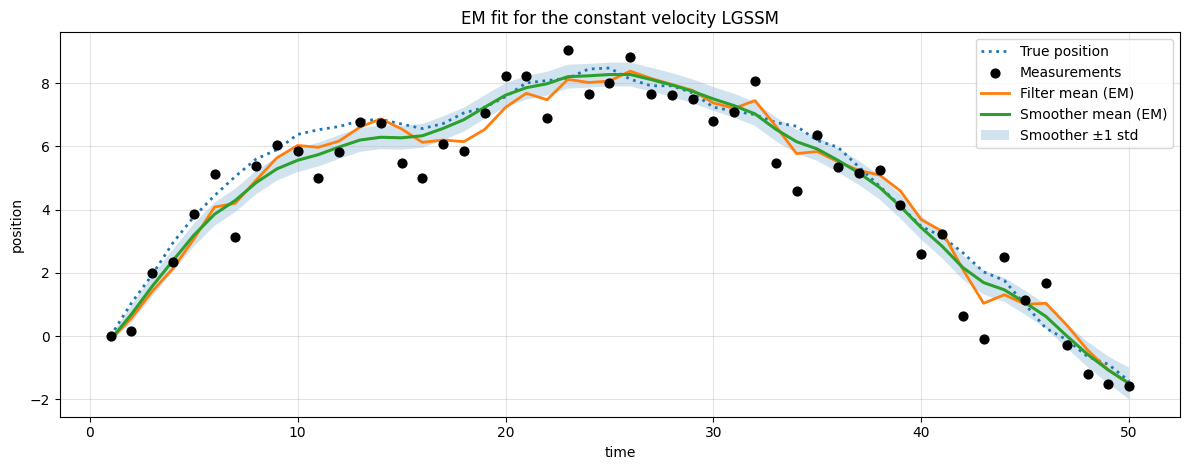

In [15]:
# Run one final filter/smoother using the EM estimates
filt_em = kalman_filter_em(xs, F_em, Q_em, H_em, R_em, m0_em, C0_em)
smooth_em = kalman_smoother_em(F_em, H_em, filt_em)

m_filt_em = filt_em["m_filt"]
C_filt_em = filt_em["C_filt"]
m_smooth_em = smooth_em["m_smooth"]
C_smooth_em = smooth_em["C_smooth"]

pos_filt_em = m_filt_em[:, 0]
pos_smooth_em = m_smooth_em[:, 0]

pos_filt_em_std = np.sqrt(C_filt_em[:, 0, 0])
pos_smooth_em_std = np.sqrt(C_smooth_em[:, 0, 0])

plt.figure(figsize=(12, 4.8))
plt.title("EM fit for the constant velocity LGSSM")

plt.plot(tgrid, true_pos, linestyle=":", linewidth=2.0, label="True position")
plt.scatter(tgrid, meas_pos, s=40, color="black", zorder=5, label="Measurements")

plt.plot(tgrid, pos_filt_em, linewidth=2.0, label="Filter mean (EM)")
plt.plot(tgrid, pos_smooth_em, linewidth=2.2, label="Smoother mean (EM)")

plt.fill_between(
    tgrid,
    pos_smooth_em - pos_smooth_em_std,
    pos_smooth_em + pos_smooth_em_std,
    alpha=0.20,
    label="Smoother ±1 std"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [16]:

# Log-likelihood for the LGSSM with fixed parameters except q and r


def kalman_loglik(xs, F, Q, H, R, m0, C0):
    """
    Compute log p(x_{1:T} | theta) via the Kalman filter.
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0.shape[0]

    m = m0.copy()
    C = C0.copy()

    loglik = 0.0

    for t in range(T):
        # prediction
        m_pred = F @ m
        C_pred = F @ C @ F.T + Q

        # innovation
        innov = xs[t] - H @ m_pred
        S = H @ C_pred @ H.T + R

        loglik += -0.5 * (
            d * np.log(2 * np.pi)
            + np.log(np.linalg.det(S))
            + innov.T @ np.linalg.solve(S, innov)
        )

        # update
        K = C_pred @ H.T @ np.linalg.inv(S)
        m = m_pred + K @ innov
        C = (np.eye(n) - K @ H) @ C_pred

    return float(loglik)


def make_Q_R(q, r):
    """
    Build Q and R from scalar variances q and r.
    """
    Q = np.array([[q, 0.0],
                  [0.0, q]])
    R = np.array([[r]])
    return Q, R


# EM restricted to q and r only
# All other parameters are fixed


def em_q_r_only(xs, F, H, m0, C0, q_init, r_init, tol=1e-6, max_iter=50):
    """
    Run EM updating only:
      q in Q = q I
      r in R = [r]

    Returns the EM path in (log q, log r).
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0.shape[0]

    q = float(q_init)
    r = float(r_init)

    path = []
    loglik_path = []

    for _ in range(max_iter):
        Q, R = make_Q_R(q, r)

        # E-step
        filt_out = kalman_filter_em(xs, F, Q, H, R, m0, C0)
        smooth_out = kalman_smoother_em(F, H, filt_out)

        m_s = smooth_out["m_smooth"]
        C_s = smooth_out["C_smooth"]
        C_lag = smooth_out["C_lag"]

        # record current iterate
        path.append((np.log(q), np.log(r)))
        loglik_path.append(filt_out["loglik"])

        # M-step for q
        S_q = np.zeros((n, n))
        for t in range(1, T):
            Ezzt = C_s[t] + np.outer(m_s[t], m_s[t])
            Ezzlag = C_lag[t] + np.outer(m_s[t], m_s[t - 1])
            Ezzprev = C_s[t - 1] + np.outer(m_s[t - 1], m_s[t - 1])

            S_q += Ezzt - F @ Ezzlag.T - Ezzlag @ F.T + F @ Ezzprev @ F.T

        Q_new = S_q / (T - 1)

        # constrain Q to q I
        q_new = np.trace(Q_new) / n

        # M-step for r
        S_r = 0.0
        for t in range(T):
            diff = xs[t] - H @ m_s[t]
            term = diff.T @ diff + H @ C_s[t] @ H.T
            S_r += term.item()

        r_new = S_r / T

        # convergence
        diff_param = np.sqrt((q_new - q) ** 2 + (r_new - r) ** 2)

        q, r = max(q_new, 1e-10), max(r_new, 1e-10)

        if diff_param <= tol:
            path.append((np.log(q), np.log(r)))
            Q, R = make_Q_R(q, r)
            loglik_path.append(kalman_loglik(xs, F, Q, H, R, m0, C0))
            break

    return {
        "q": q,
        "r": r,
        "path": np.array(path),
        "loglik_path": np.array(loglik_path),
    }


# Build the log-likelihood surface on a grid


def loglik_surface_q_r(xs, F, H, m0, C0, q_vals, r_vals):
    """
    Evaluate log-likelihood on a grid of q and r values.
    """
    Z = np.zeros((len(r_vals), len(q_vals)))

    for i, r in enumerate(r_vals):
        for j, q in enumerate(q_vals):
            Q, R = make_Q_R(q, r)
            Z[i, j] = kalman_loglik(xs, F, Q, H, R, m0, C0)

    return Z

In [17]:
# Choose initial guess for EM
q_init = 0.8
r_init = 0.35

em_out_qr = em_q_r_only(
    xs=xs,
    F=F,
    H=H,
    m0=m0,
    C0=C0,
    q_init=q_init,
    r_init=r_init,
    tol=1e-12,
    max_iter=5000000
)

print("EM estimate of q:", em_out_qr["q"])
print("EM estimate of r:", em_out_qr["r"])

EM estimate of q: 0.01774254392314062
EM estimate of r: 0.714782527997641


In [18]:
q_true = 0.02
r_true = 1.0

path = em_out_qr["path"]

log_q_all = np.concatenate([path[:, 0], [np.log(q_true)]])
log_r_all = np.concatenate([path[:, 1], [np.log(r_true)]])

pad_q = 0.6
pad_r = 0.6

log_q_vals = np.linspace(log_q_all.min() - pad_q, log_q_all.max() + pad_q, 140)
log_r_vals = np.linspace(log_r_all.min() - pad_r, log_r_all.max() + pad_r, 140)

q_vals = np.exp(log_q_vals)
r_vals = np.exp(log_r_vals)

Z = loglik_surface_q_r(xs, F, H, m0, C0, q_vals, r_vals)

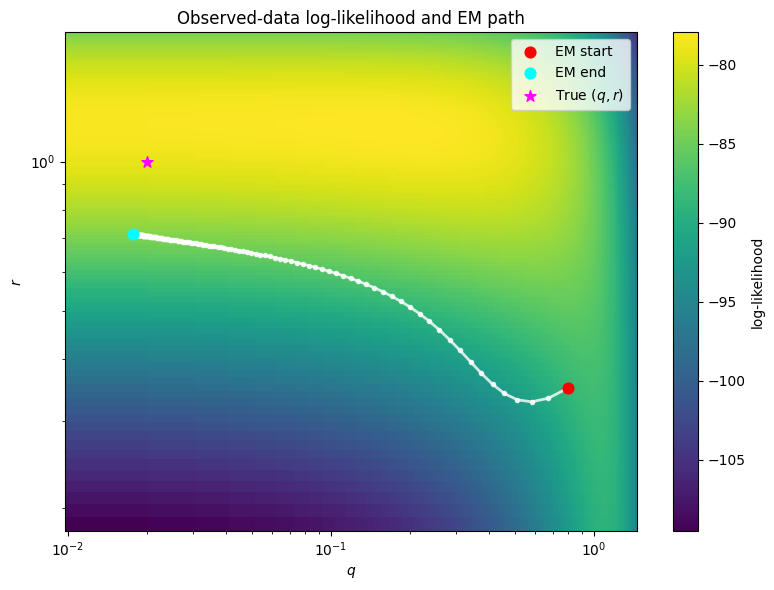

In [19]:
q_true = 0.02
r_true = 1.0

plt.figure(figsize=(8, 6))

plt.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[q_vals[0], q_vals[-1], r_vals[0], r_vals[-1]]
)

plt.colorbar(label="log-likelihood")

path = em_out_qr["path"]
path_q = np.exp(path[:, 0])
path_r = np.exp(path[:, 1])

plt.plot(path_q, path_r, color="white", linewidth=2.0, marker="o", markersize=3, alpha=0.8)
plt.scatter(path_q[0], path_r[0], color="red", s=60, label="EM start", zorder=5)
plt.scatter(path_q[-1], path_r[-1], color="cyan", s=60, label="EM end", zorder=5)
plt.scatter(q_true, r_true, color="magenta", s=70, marker="*", label="True $(q,r)$", zorder=6)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$q$")
plt.ylabel(r"$r$")
plt.title("Observed-data log-likelihood and EM path")
plt.legend()
plt.tight_layout()
plt.show()

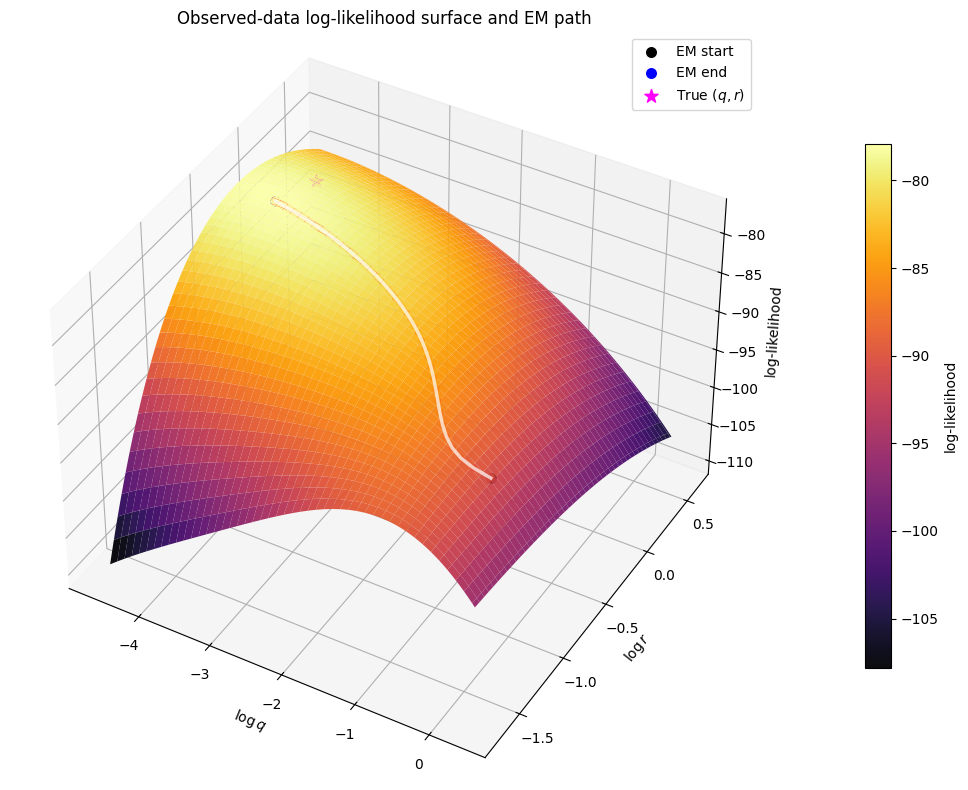

In [20]:
from mpl_toolkits.mplot3d import Axes3D

q_true = 0.02
r_true = 1.0

path = em_out_qr["path"]
path_loglik = np.array([
    kalman_loglik(
        xs=xs,
        F=F,
        Q=make_Q_R(np.exp(lq), np.exp(lr))[0],
        H=H,
        R=make_Q_R(np.exp(lq), np.exp(lr))[1],
        m0=m0,
        C0=C0
    )
    for lq, lr in path
])

true_loglik = kalman_loglik(
    xs=xs,
    F=F,
    Q=make_Q_R(q_true, r_true)[0],
    H=H,
    R=make_Q_R(q_true, r_true)[1],
    m0=m0,
    C0=C0
)

LQ, LR = np.meshgrid(log_q_vals, log_r_vals)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    LQ, LR, Z,
    cmap="inferno",
    linewidth=0,
    antialiased=True,
    alpha=0.95
)

ax.plot(
    path[:, 0],
    path[:, 1],
    path_loglik,
    color="white",
    linewidth=2.5,
    alpha=0.7,
    zorder=10
)
ax.scatter(
    path[:, 0],
    path[:, 1],
    path_loglik,
    color="red",
    s=20,
    alpha=0.6,
    zorder=11
)

ax.scatter(path[0, 0], path[0, 1], path_loglik[0], color="black", s=80, edgecolors="white", linewidth=1, label="EM start", zorder=12)
ax.scatter(path[-1, 0], path[-1, 1], path_loglik[-1], color="blue", s=80, edgecolors="white", linewidth=1, label="EM end")
ax.scatter(np.log(q_true), np.log(r_true), true_loglik, color="magenta", s=100, marker="*", label="True $(q,r)$")

ax.set_xlabel(r"$\log q$")
ax.set_ylabel(r"$\log r$")
ax.set_zlabel("log-likelihood")
ax.set_title("Observed-data log-likelihood surface and EM path")

fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label="log-likelihood")
ax.view_init(elev=40, azim=-60)
ax.legend()

plt.tight_layout()
plt.show()